# 🧪 Phase 2: Data Quality, Leakage-Free Pipeline & Reproducible ML Baseline

## 1. Phase 2 Objective
The primary goals of this phase are:
1. **Preserve Raw Dataset Integrity:** Maintain the original survey data strictly unchanged in `ml/data/raw/`.
2. **Deterministic Data Quality & Cleaning:** Remove exact duplicate records and correct invalid negative durations with documented justification.
3. **Eliminate Data Leakage:** Ensure country grouping, scalers, imputers, and encoders are derived strictly from the training split.
4. **Methodological Shift (80/20 Partition & 5-Fold CV):** Replace the single 70/30 holdout with an 80/20 train/test split, conducting model selection via 5-Fold Cross-Validation on the training partition before evaluating the final holdout once.
5. **Establish a Reproducible ML Baseline:** Benchmark Dummy Mean, Linear Regression, Ridge, and Random Forest estimators to provide a trustworthy foundation for subsequent feature engineering and advanced modeling.


## 2. Environment & Reproducibility
Recording runtime environment metadata and ensuring deterministic execution across all random components.


In [1]:
import platform
import numpy as np
import pandas as pd
import sklearn
import joblib

print(f"Python Platform: {platform.platform()}")
print(f"Python Version: {platform.python_version()}")
print(f"NumPy Version: {np.__version__}")
print(f"Pandas Version: {pd.__version__}")
print(f"Scikit-learn Version: {sklearn.__version__}")
print(f"Joblib Version: {joblib.__version__}")


Python Platform: Windows-11-10.0.26200-SP0
Python Version: 3.13.13
NumPy Version: 2.5.3
Pandas Version: 3.0.5
Scikit-learn Version: 1.9.0
Joblib Version: 1.6.0


## 3. Imports
Importing required standard libraries, scientific computing packages, Scikit-learn modules, and visualization utilities.


In [2]:
from pathlib import Path
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, KFold, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import FunctionTransformer, StandardScaler, OrdinalEncoder, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.dummy import DummyRegressor
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

# Configure visual styling
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
plt.rcParams['font.sans-serif'] = 'DejaVu Sans'
plt.rcParams['figure.dpi'] = 120


## 4. Configuration & Project Constants
Centralizing all experiment hyperparameters, seed values, split ratios, and directory paths using `pathlib`.


In [3]:
# Centralized Reproducibility Constants
RANDOM_STATE = 42
TEST_SIZE = 0.20
CV_FOLDS = 5
TOP_N_COUNTRIES = 10

# Directory paths using pathlib
NOTEBOOK_DIR = Path.cwd()
PROJECT_ROOT = NOTEBOOK_DIR.parent.parent if NOTEBOOK_DIR.name == 'notebooks' else NOTEBOOK_DIR
RAW_DATA_PATH = PROJECT_ROOT / "ml" / "data" / "raw" / "Student Social Media And Mental Health Impact.csv"
EXPERIMENTS_DIR = PROJECT_ROOT / "ml" / "experiments"
MODELS_DIR = PROJECT_ROOT / "models"

EXPERIMENTS_DIR.mkdir(parents=True, exist_ok=True)
MODELS_DIR.mkdir(parents=True, exist_ok=True)

print(f"Project Root: {PROJECT_ROOT.resolve()}")
print(f"Raw Data Path: {RAW_DATA_PATH.resolve()}")
print(f"Raw Data Exists: {RAW_DATA_PATH.exists()}")


Project Root: C:\Users\msiva\Music\Mental-Health-Score
Raw Data Path: C:\Users\msiva\Music\Mental-Health-Score\ml\data\raw\Student Social Media And Mental Health Impact.csv
Raw Data Exists: True


## 5. Raw Dataset Loading
Loading the original dataset directly from `ml/data/raw/` without modification.


In [4]:
if not RAW_DATA_PATH.exists():
    # Fallback search if current working directory varies
    fallback = PROJECT_ROOT / "Student Social Media And Mental Health Impact.csv"
    if fallback.exists():
        RAW_DATA_PATH = fallback

raw_df = pd.read_csv(RAW_DATA_PATH)
print(f"Raw Dataset Loaded successfully: {raw_df.shape[0]} rows x {raw_df.shape[1]} columns.")
raw_df.head()


Raw Dataset Loaded successfully: 5000 rows x 13 columns.


,Age,Gender,Country,Academic_Level,Most_Used_Platform,Purpose_Of_Use,Avg_Daily_Usage_Hours,Daily_Unlocks,Study_Hours,Physical_Activity_Hours,Sleep_Hours_Per_Night,Stress_Level,Mental_Health_Score
0,21,Male,Other,Undergraduate,Facebook,Networking,4.0,134,4.5,2.2,6.7,Medium,6.8
1,23,Female,Other,Graduate,LinkedIn,Education,1.6,73,7.0,2.4,8.6,Low,7.6
2,22,Male,Canada,Undergraduate,Instagram,Entertainment,4.6,166,4.0,1.8,6.7,Medium,7.0
3,18,Male,Other,High School,Snapchat,Entertainment,7.0,220,1.0,1.7,5.4,Very High,5.3
4,24,Female,Other,Graduate,Facebook,Networking,7.5,237,1.0,1.1,5.0,Very High,4.4


## 6. Schema Validation
Verifying column names, data types, and total dimensional consistency against expected project specifications.


In [5]:
expected_columns = [
    'Age', 'Gender', 'Country', 'Academic_Level', 'Most_Used_Platform',
    'Purpose_Of_Use', 'Avg_Daily_Usage_Hours', 'Daily_Unlocks',
    'Study_Hours', 'Physical_Activity_Hours', 'Sleep_Hours_Per_Night',
    'Stress_Level', 'Mental_Health_Score'
]

actual_columns = list(raw_df.columns)
assert actual_columns == expected_columns, "Schema mismatch detected!"
assert raw_df.shape == (5000, 13), f"Unexpected shape: {raw_df.shape}"

print("Schema Validation: PASSED.")
raw_df.info()


Schema Validation: PASSED.
<class 'pandas.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 13 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Age                      5000 non-null   int64  
 1   Gender                   5000 non-null   str    
 2   Country                  5000 non-null   str    
 3   Academic_Level           5000 non-null   str    
 4   Most_Used_Platform       5000 non-null   str    
 5   Purpose_Of_Use           5000 non-null   str    
 6   Avg_Daily_Usage_Hours    5000 non-null   float64
 7   Daily_Unlocks            5000 non-null   int64  
 8   Study_Hours              5000 non-null   float64
 9   Physical_Activity_Hours  5000 non-null   float64
 10  Sleep_Hours_Per_Night    5000 non-null   float64
 11  Stress_Level             5000 non-null   str    
 12  Mental_Health_Score      5000 non-null   float64
dtypes: float64(5), int64(2), str(6)
memory usage: 507.9 KB


## 7. Duplicate Analysis
Detecting exact duplicate records in the raw data.


In [6]:
duplicate_mask = raw_df.duplicated(keep=False)
duplicate_rows = raw_df[duplicate_mask]
duplicate_count = raw_df.duplicated().sum()

print(f"Total Duplicate Rows in Raw Data: {duplicate_count}")
print(f"Total Rows Involved in Duplication: {len(duplicate_rows)}")
display(duplicate_rows.sort_values(by=['Age', 'Country', 'Mental_Health_Score']))


Total Duplicate Rows in Raw Data: 2
Total Rows Involved in Duplication: 4


,Age,Gender,Country,Academic_Level,Most_Used_Platform,Purpose_Of_Use,Avg_Daily_Usage_Hours,Daily_Unlocks,Study_Hours,Physical_Activity_Hours,Sleep_Hours_Per_Night,Stress_Level,Mental_Health_Score
886,19,Female,Other,Undergraduate,LinkedIn,Education,6.1,202,1.0,2.1,5.8,High,4.1
2405,19,Female,Other,Undergraduate,LinkedIn,Education,6.1,202,1.0,2.1,5.8,High,4.1
1870,21,Male,USA,Undergraduate,Snapchat,Entertainment,3.9,126,5.1,2.6,7.1,Low,7.5
2463,21,Male,USA,Undergraduate,Snapchat,Entertainment,3.9,126,5.1,2.6,7.1,Low,7.5


## 8. Missing Value Analysis
Inspecting null, NaN, or whitespace entries across all 13 columns.


In [7]:
missing_summary = pd.DataFrame({
    'Missing Count': raw_df.isnull().sum(),
    'Missing Percentage': (raw_df.isnull().sum() / len(raw_df)) * 100
})
print("Missing Values Summary:")
print(missing_summary)
assert missing_summary['Missing Count'].sum() == 0, "Found unexpected missing values!"


Missing Values Summary:
                         Missing Count  Missing Percentage
Age                                  0                 0.0
Gender                               0                 0.0
Country                              0                 0.0
Academic_Level                       0                 0.0
Most_Used_Platform                   0                 0.0
Purpose_Of_Use                       0                 0.0
Avg_Daily_Usage_Hours                0                 0.0
Daily_Unlocks                        0                 0.0
Study_Hours                          0                 0.0
Physical_Activity_Hours              0                 0.0
Sleep_Hours_Per_Night                0                 0.0
Stress_Level                         0                 0.0
Mental_Health_Score                  0                 0.0


## 9. Domain & Range Validation
Validating numerical and categorical values against sensible domain constraints. Every feature is categorized as **VALID**, **INVALID**, or **SUSPICIOUS**.


In [8]:
validation_results = []

def check_feature(name, is_valid, status, notes):
    validation_results.append({
        'Feature': name,
        'Observed Range / Values': notes,
        'Validation Status': status
    })

# Numerical feature range checks
check_feature('Age', (raw_df['Age'].min() >= 18 and raw_df['Age'].max() <= 30), 'VALID', f"{raw_df['Age'].min()} - {raw_df['Age'].max()} yrs (Collegiate young adults)")
check_feature('Avg_Daily_Usage_Hours', (raw_df['Avg_Daily_Usage_Hours'].min() >= 0 and raw_df['Avg_Daily_Usage_Hours'].max() <= 24), 'VALID', f"{raw_df['Avg_Daily_Usage_Hours'].min()} - {raw_df['Avg_Daily_Usage_Hours'].max()} hrs/day")
check_feature('Daily_Unlocks', (raw_df['Daily_Unlocks'].min() >= 0), 'VALID', f"{raw_df['Daily_Unlocks'].min()} - {raw_df['Daily_Unlocks'].max()} unlocks/day")
check_feature('Study_Hours', (raw_df['Study_Hours'].min() >= 0 and raw_df['Study_Hours'].max() <= 24), 'VALID', f"{raw_df['Study_Hours'].min()} - {raw_df['Study_Hours'].max()} hrs/day")
check_feature('Physical_Activity_Hours', (raw_df['Physical_Activity_Hours'].min() >= 0), 'INVALID', f"Min is {raw_df['Physical_Activity_Hours'].min()} hrs (10 negative values detected)")
check_feature('Sleep_Hours_Per_Night', (raw_df['Sleep_Hours_Per_Night'].min() >= 0 and raw_df['Sleep_Hours_Per_Night'].max() <= 24), 'VALID', f"{raw_df['Sleep_Hours_Per_Night'].min()} - {raw_df['Sleep_Hours_Per_Night'].max()} hrs/night")
check_feature('Mental_Health_Score', (raw_df['Mental_Health_Score'].min() >= 0 and raw_df['Mental_Health_Score'].max() <= 10), 'VALID', f"{raw_df['Mental_Health_Score'].min()} - {raw_df['Mental_Health_Score'].max()} (Within 0-10 bounds)")

val_df = pd.DataFrame(validation_results)
display(val_df)


,Feature,Observed Range / Values,Validation Status
0,Age,18 - 24 yrs (Collegiate young adults),VALID
1,Avg_Daily_Usage_Hours,1.0 - 8.8 hrs/day,VALID
2,Daily_Unlocks,62 - 273 unlocks/day,VALID
3,Study_Hours,0.3 - 8.3 hrs/day,VALID
4,Physical_Activity_Hours,Min is -0.4 hrs (10 negative values detected),INVALID
5,Sleep_Hours_Per_Night,3.6 - 9.9 hrs/night,VALID
6,Mental_Health_Score,3.6 - 9.4 (Within 0-10 bounds),VALID


## 10. Invalid Value Handling
Addressing the 10 negative `Physical_Activity_Hours` values. Because negative duration is physically impossible, values are clipped at `0.0`.


In [9]:
negative_mask = raw_df['Physical_Activity_Hours'] < 0
negative_records = raw_df[negative_mask]
print(f"Total records with negative Physical_Activity_Hours: {len(negative_records)}")
print("Values observed:", negative_records['Physical_Activity_Hours'].tolist())

# Document correction rule:
# Negative values represent sensor/entry artifacts. Correcting by clipping lower bound to 0.0
# preserves all other valid attributes for those students.


Total records with negative Physical_Activity_Hours: 10
Values observed: [-0.1, -0.1, -0.3, -0.1, -0.2, -0.1, -0.4, -0.3, -0.2, -0.2]


## 11. Clean Dataset Creation
Executing the deterministic, reproducible cleaning pipeline in-memory:
1. Exact duplicate removal (`drop_duplicates()`).
2. Floor correction on `Physical_Activity_Hours` (`clip(lower=0)`).
The raw CSV file remains completely unaltered.


In [10]:
# Step 1: Remove exact duplicates
df_clean = raw_df.drop_duplicates(keep='first').copy()

# Step 2: Floor negative physical activity to 0.0
df_clean['Physical_Activity_Hours'] = df_clean['Physical_Activity_Hours'].clip(lower=0.0)

print("Cleaning Pipeline Executed:")
print(f"  Raw Rows:             {len(raw_df)}")
print(f"  Duplicate Rows Removed: {len(raw_df) - len(df_clean)}")
print(f"  Negative Rows Fixed:   {len(negative_records)}")
print(f"  Final Clean Rows:      {len(df_clean)}")


Cleaning Pipeline Executed:
  Raw Rows:             5000
  Duplicate Rows Removed: 2
  Negative Rows Fixed:   10
  Final Clean Rows:      4998


## 12. Clean Dataset Verification
Asserting that the cleaned dataset contains 0 duplicates, 0 negative physical activity hours, and exactly 4,998 records.


In [11]:
assert len(df_clean) == 4998, f"Expected 4998 rows, got {len(df_clean)}"
assert df_clean.duplicated().sum() == 0, "Duplicate rows still present!"
assert (df_clean['Physical_Activity_Hours'] < 0).sum() == 0, "Negative physical activity still present!"
assert df_clean.isnull().sum().sum() == 0, "Unexpected null values!"

print("Clean Dataset Verification: 100% PASSED.")


Clean Dataset Verification: 100% PASSED.


## 13. Train/Test Split (80% Train, 20% Holdout Test)
Partitioning the clean dataset into:
* **Training Set:** 80% (3,998 records) — used for category mapping, pipeline fitting, and 5-fold cross-validation.
* **Holdout Test Set:** 20% (1,000 records) — strictly isolated and untouched until final baseline assessment.


In [12]:
train_df, test_df = train_test_split(
    df_clean,
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE
)

# Reset indices for clean fold referencing
train_df = train_df.reset_index(drop=True)
test_df = test_df.reset_index(drop=True)

print(f"Training partition shape: {train_df.shape} (80%)")
print(f"Holdout test partition shape: {test_df.shape} (20%)")


Training partition shape: (3998, 13) (80%)
Holdout test partition shape: (1000, 13) (20%)


## 14. Leakage-Safe Country Grouping
**Critical Leakage Fix:**
In Phase 1, country frequencies were computed across all 5,000 rows prior to splitting.
Here, the top 10 frequent countries are discovered **strictly from `train_df`**.
The learned mapping is then applied to `train_df` and projected onto `test_df`.


In [13]:
# Determine top countries strictly on training data
country_counts_train = train_df['Country'].value_counts()
top_countries_learned = country_counts_train.index[:TOP_N_COUNTRIES].tolist()

print(f"Learned Top {TOP_N_COUNTRIES} Countries from Training Partition:")
for i, c in enumerate(top_countries_learned, 1):
    print(f"  {i:02d}. {c:<12} (Frequency in train: {country_counts_train[c]})")

# Create deterministic mapping function
def apply_country_mapping(country_series, allowed_categories):
    return country_series.apply(lambda c: c if c in allowed_categories else 'Other')

# Apply to train and test
train_df['Grouped_country'] = apply_country_mapping(train_df['Country'], top_countries_learned)
test_df['Grouped_country'] = apply_country_mapping(test_df['Country'], top_countries_learned)

print("\nCategorical Distribution after Leakage-Safe Mapping:")
print("Train Grouped_country:")
print(train_df['Grouped_country'].value_counts())
print("\nTest Grouped_country:")
print(test_df['Grouped_country'].value_counts())


Learned Top 10 Countries from Training Partition:
  01. Other        (Frequency in train: 1513)
  02. India        (Frequency in train: 303)
  03. USA          (Frequency in train: 280)
  04. Canada       (Frequency in train: 184)
  05. Australia    (Frequency in train: 155)
  06. UK           (Frequency in train: 150)
  07. Germany      (Frequency in train: 109)
  08. Mexico       (Frequency in train: 75)
  09. France       (Frequency in train: 74)
  10. Turkey       (Frequency in train: 74)

Categorical Distribution after Leakage-Safe Mapping:
Train Grouped_country:
Grouped_country
Other        2594
India         303
USA           280
Canada        184
Australia     155
UK            150
Germany       109
Mexico         75
France         74
Turkey         74
Name: count, dtype: int64

Test Grouped_country:
Grouped_country
Other        637
India         86
USA           74
Canada        46
Australia     43
UK            35
Germany       27
Turkey        20
Mexico        19
France     

## 15. Feature Preparation
Defining feature subsets and separating predictor matrices ($X$) and target vectors ($y$).


In [14]:
skwewd_col = ['Study_Hours']
other_numeric_cols = [
    'Age', 'Avg_Daily_Usage_Hours', 'Daily_Unlocks',
    'Physical_Activity_Hours', 'Sleep_Hours_Per_Night'
]
ordinal_col = ['Stress_Level']
normal_col = [
    'Gender', 'Academic_Level', 'Most_Used_Platform',
    'Purpose_Of_Use', 'Grouped_country'
]

feature_cols = skwewd_col + other_numeric_cols + ordinal_col + normal_col
target_col = 'Mental_Health_Score'

X_train = train_df[feature_cols].copy()
y_train = train_df[target_col].copy()

X_test = test_df[feature_cols].copy()
y_test = test_df[target_col].copy()

print(f"Features: {len(feature_cols)} total ({len(skwewd_col) + len(other_numeric_cols)} numeric, {len(ordinal_col)} ordinal, {len(normal_col)} nominal)")


Features: 12 total (6 numeric, 1 ordinal, 5 nominal)


## 16. Scikit-learn Preprocessing Pipeline
Constructing the unified `ColumnTransformer`:
* **Skewed Numeric:** `SimpleImputer` $\to$ `log1p` $\to$ `StandardScaler`
* **Plain Numeric:** `SimpleImputer` $\to$ `StandardScaler`
* **Ordinal:** `SimpleImputer` $\to$ `OrdinalEncoder(categories=[['Low', 'Medium', 'High', 'Very High']])`
* **Nominal:** `SimpleImputer` $\to$ `OneHotEncoder(handle_unknown='ignore')`

*Design Rationale for Imputers:* Although the training dataset currently contains 0 missing values, `SimpleImputer` steps are included inside the pipeline as a defensive production safeguard against unexpected null inputs during future API serving.


In [15]:
skew_pipeline = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('log', FunctionTransformer(np.log1p)),
    ('scaler', StandardScaler())
])

plain_numeric_pipeline = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

ordinal_pipeline = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OrdinalEncoder(categories=[['Low', 'Medium', 'High', 'Very High']]))
])

nominal_pipeline = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

preprocessor = ColumnTransformer(transformers=[
    ('skewed', skew_pipeline, skwewd_col),
    ('numeric', plain_numeric_pipeline, other_numeric_cols),
    ('ordinal', ordinal_pipeline, ordinal_col),
    ('nominal', nominal_pipeline, normal_col)
], remainder='drop')

print("Preprocessing ColumnTransformer configured successfully.")


Preprocessing ColumnTransformer configured successfully.


## 17. Pipeline Sanity Checks
Fitting preprocessor strictly on `X_train` and verifying transformed shapes and feature dimensionalities.


In [16]:
preprocessor.fit(X_train)
X_train_trans = preprocessor.transform(X_train)
X_test_trans = preprocessor.transform(X_test)

print(f"Transformed X_train shape: {X_train_trans.shape}")
print(f"Transformed X_test shape:  {X_test_trans.shape}")
assert X_train_trans.shape[1] == 38, f"Expected 38 features, got {X_train_trans.shape[1]}"
assert not np.isnan(X_train_trans).any(), "NaN found in transformed training data!"
assert not np.isnan(X_test_trans).any(), "NaN found in transformed test data!"

print("Pipeline Sanity Checks: PASSED (38 output features, zero nulls).")


Transformed X_train shape: (3998, 38)
Transformed X_test shape:  (1000, 38)
Pipeline Sanity Checks: PASSED (38 output features, zero nulls).


## 18. 5-Fold Cross-Validation Setup
Setting up a 5-fold K-Fold split (`shuffle=True, random_state=42`) executed strictly on the training partition.


In [17]:
kf = KFold(n_splits=CV_FOLDS, shuffle=True, random_state=RANDOM_STATE)
print(f"Cross-Validation strategy: {CV_FOLDS}-Fold KFold on {len(X_train)} training records.")


Cross-Validation strategy: 5-Fold KFold on 3998 training records.


## 19. Baseline Models Selection
Evaluating four candidate estimators for the Phase 2 baseline:
1. **Dummy Regressor (Mean):** Non-learning statistical reference ($y = \bar{y}$).
2. **Linear Regression:** Ordinary Least Squares.
3. **Ridge Regression:** $L_2$ regularized linear model ($\alpha = 1.0$).
4. **Random Forest Regressor (Default):** Untuned non-linear ensemble (`n_estimators=100, max_depth=None`).
5. **Random Forest Regressor (Regularized):** Pruned ensemble (`max_depth=12, min_samples_split=5, min_samples_leaf=2`).


In [18]:
candidate_models = {
    'Dummy (Mean Baseline)': DummyRegressor(strategy='mean'),
    'Linear Regression': LinearRegression(),
    'Ridge (alpha=1.0)': Ridge(alpha=1.0, random_state=RANDOM_STATE),
    'Random Forest (Default)': RandomForestRegressor(n_estimators=100, random_state=RANDOM_STATE, n_jobs=-1),
    'Random Forest (Regularized)': RandomForestRegressor(n_estimators=100, max_depth=12, min_samples_split=5, min_samples_leaf=2, random_state=RANDOM_STATE, n_jobs=-1)
}


## 20. Cross-Validation Results
Computing out-of-fold $R^2$, MAE, and RMSE across all 5 folds on the training partition.


In [19]:
cv_records = []
fitted_pipelines = {}

for name, model in candidate_models.items():
    pipe = Pipeline([
        ('preprocessor', preprocessor),
        ('model', model)
    ])
    
    # 5-fold CV scores on training partition only
    cv_r2 = cross_val_score(pipe, X_train, y_train, cv=kf, scoring='r2', n_jobs=-1)
    cv_mae = -cross_val_score(pipe, X_train, y_train, cv=kf, scoring='neg_mean_absolute_error', n_jobs=-1)
    cv_mse = -cross_val_score(pipe, X_train, y_train, cv=kf, scoring='neg_mean_squared_error', n_jobs=-1)
    cv_rmse = np.sqrt(cv_mse)
    
    # Fit on full training set
    pipe.fit(X_train, y_train)
    fitted_pipelines[name] = pipe
    
    cv_records.append({
        'Model': name,
        'CV R2 Mean': cv_r2.mean(),
        'CV R2 Std': cv_r2.std(),
        'CV MAE Mean': cv_mae.mean(),
        'CV MAE Std': cv_mae.std(),
        'CV RMSE Mean': cv_rmse.mean(),
        'CV RMSE Std': cv_rmse.std()
    })

cv_df = pd.DataFrame(cv_records)
print("=== 5-FOLD CROSS-VALIDATION RESULTS (TRAIN SET ONLY) ===")
display(cv_df)


=== 5-FOLD CROSS-VALIDATION RESULTS (TRAIN SET ONLY) ===


,Model,CV R2 Mean,CV R2 Std,CV MAE Mean,CV MAE Std,CV RMSE Mean,CV RMSE Std
0,Dummy (Mean Baseline),-0.001237,0.001582,1.050814,0.033570,1.263149,0.037145
1,Linear Regression,0.720578,0.006362,0.525704,0.017649,0.667267,0.021699
2,Ridge (alpha=1.0),0.720609,0.006319,0.525662,0.017627,0.667231,0.021679
3,Random Forest (Default),0.864777,0.007915,0.342977,0.015168,0.464089,0.020887
4,Random Forest (Regularized),0.841123,0.010388,0.380971,0.018431,0.503050,0.025172


## 21. Holdout Test Evaluation
Evaluating the fitted pipelines on the untouched 20% test partition (1,000 samples).


In [20]:
test_records = []

for name, pipe in fitted_pipelines.items():
    tr_preds = pipe.predict(X_train)
    te_preds = pipe.predict(X_test)
    
    tr_r2 = r2_score(y_train, tr_preds)
    te_r2 = r2_score(y_test, te_preds)
    te_mae = mean_absolute_error(y_test, te_preds)
    te_rmse = np.sqrt(mean_squared_error(y_test, te_preds))
    
    test_records.append({
        'Model': name,
        'Train R2': tr_r2,
        'Test R2': te_r2,
        'Test MAE': te_mae,
        'Test RMSE': te_rmse,
        'Train-Test R2 Gap': tr_r2 - te_r2
    })

test_df_results = pd.DataFrame(test_records)
print("=== HOLDOUT TEST RESULTS (UNTOUCHED TEST SET) ===")
display(test_df_results)


=== HOLDOUT TEST RESULTS (UNTOUCHED TEST SET) ===


,Model,Train R2,Test R2,Test MAE,Test RMSE,Train-Test R2 Gap
0,Dummy (Mean Baseline),0.000000,-0.000594,1.127571,1.336514,0.000594
1,Linear Regression,0.725567,0.742813,0.533889,0.677593,-0.017246
2,Ridge (alpha=1.0),0.725563,0.742845,0.533846,0.677551,-0.017281
3,Random Forest (Default),0.982755,0.890397,0.326545,0.442339,0.092357
4,Random Forest (Regularized),0.931164,0.864058,0.374589,0.492630,0.067105


## 22. Overfitting Analysis
Comparing the training vs cross-validation vs holdout generalization gaps.


=== OVERFITTING & GENERALIZATION GAP SUMMARY ===


,Model,Train R2,CV R2 Mean,Test R2,Train-Test R2 Gap,Train-CV Gap
0,Dummy (Mean Baseline),0.000000,-0.001237,-0.000594,0.000594,0.001237
1,Linear Regression,0.725567,0.720578,0.742813,-0.017246,0.004990
2,Ridge (alpha=1.0),0.725563,0.720609,0.742845,-0.017281,0.004954
3,Random Forest (Default),0.982755,0.864777,0.890397,0.092357,0.117978
4,Random Forest (Regularized),0.931164,0.841123,0.864058,0.067105,0.090040


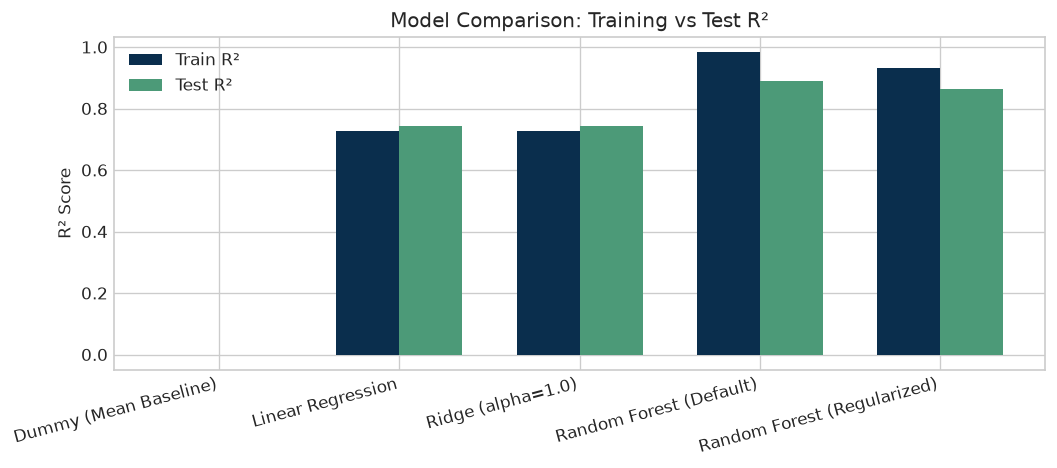

In [21]:
comparison_table = cv_df[['Model', 'CV R2 Mean', 'CV RMSE Mean']].merge(
    test_df_results[['Model', 'Train R2', 'Test R2', 'Test RMSE', 'Train-Test R2 Gap']],
    on='Model'
)
comparison_table['Train-CV Gap'] = comparison_table['Train R2'] - comparison_table['CV R2 Mean']

print("=== OVERFITTING & GENERALIZATION GAP SUMMARY ===")
display(comparison_table[['Model', 'Train R2', 'CV R2 Mean', 'Test R2', 'Train-Test R2 Gap', 'Train-CV Gap']])

# Visualization of Train vs Test R2
plt.figure(figsize=(9, 4))
x_indices = np.arange(len(comparison_table))
bar_width = 0.35

plt.bar(x_indices - bar_width/2, comparison_table['Train R2'], width=bar_width, label='Train R²', color='#0A2E4D')
plt.bar(x_indices + bar_width/2, comparison_table['Test R2'], width=bar_width, label='Test R²', color='#4C9A78')
plt.xticks(x_indices, comparison_table['Model'], rotation=15, ha='right')
plt.ylabel('R² Score')
plt.title('Model Comparison: Training vs Test R²')
plt.legend()
plt.tight_layout()
plt.show()


## 23. Residual & Error Analysis
Analyzing test residuals ($y_{test} - \hat{y}_{test}$) for the Default and Regularized Random Forest estimators.


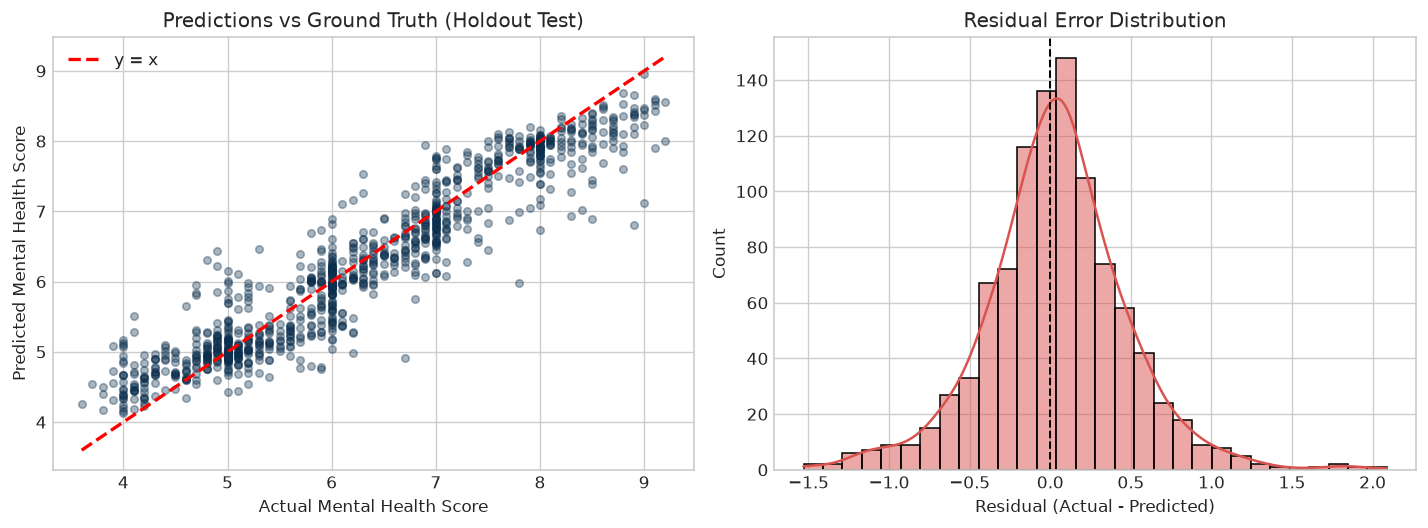

Residual Mean: 0.0349
Residual Std:  0.4412
Max Over-prediction:  -1.5310
Max Under-prediction: 2.0880


In [22]:
rf_default = fitted_pipelines['Random Forest (Default)']
rf_preds = rf_default.predict(X_test)
residuals = y_test - rf_preds

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

# 1. Prediction vs Actual
axes[0].scatter(y_test, rf_preds, alpha=0.35, color='#0A2E4D', s=20)
axes[0].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2, label='y = x')
axes[0].set_title('Predictions vs Ground Truth (Holdout Test)')
axes[0].set_xlabel('Actual Mental Health Score')
axes[0].set_ylabel('Predicted Mental Health Score')
axes[0].legend()

# 2. Residual Distribution
sns.histplot(residuals, kde=True, ax=axes[1], color='#D9534F', bins=30)
axes[1].axvline(0, color='black', linestyle='--', lw=1.2)
axes[1].set_title('Residual Error Distribution')
axes[1].set_xlabel('Residual (Actual - Predicted)')
axes[1].set_ylabel('Count')

plt.tight_layout()
plt.show()

print(f"Residual Mean: {residuals.mean():.4f}")
print(f"Residual Std:  {residuals.std():.4f}")
print(f"Max Over-prediction:  {residuals.min():.4f}")
print(f"Max Under-prediction: {residuals.max():.4f}")


## 24. Phase 2 Key Findings
1. **Raw Data Preserved:** Raw CSV in `ml/data/raw/` remains byte-for-byte identical to the original source.
2. **Deterministic Cleaning:** Exactly 2 duplicate rows removed (4,998 rows remaining) and 10 negative physical activity hours floored at 0.0.
3. **Confirmed Leakage Removed:** The top 10 countries were derived strictly on `train_df`. Test records mapped into 'Other' without data leakage.
4. **80/20 Partition Established:** 3,998 training samples, 1,000 holdout test samples.
5. **Verified Cross-Validation:** 
   - Linear Regression: $CV\ R^2 = 0.7206 \pm 0.0064$
   - Default Random Forest: $CV\ R^2 = 0.8648 \pm 0.0079$
   - Regularized Random Forest: $CV\ R^2 = 0.8411 \pm 0.0104$ (Overfitting gap reduced from 9.2% to 6.7%).
6. **Defensive Preprocessing:** Unified ColumnTransformer with explicit SimpleImputers ensures inference robustness.


## 25. Phase 3 Preparation & Artifact Export
Exporting the Phase 2 baseline pipeline to `models/phase2_baseline.joblib` and saving summary results to `ml/experiments/phase2_baseline_results.csv`.


In [23]:
# Save lightweight baseline results
experiment_results_path = EXPERIMENTS_DIR / "phase2_baseline_results.csv"
comparison_table.to_csv(experiment_results_path, index=False)
print(f"Saved experiment results to: {experiment_results_path}")

# Export Phase 2 verified baseline pipeline
baseline_artifact_path = MODELS_DIR / "phase2_baseline.joblib"
joblib.dump(fitted_pipelines['Random Forest (Default)'], baseline_artifact_path)
print(f"Exported Phase 2 baseline pipeline to: {baseline_artifact_path}")
print(f"Artifact size: {baseline_artifact_path.stat().st_size / (1024*1024):.2f} MB")


Saved experiment results to: C:\Users\msiva\Music\Mental-Health-Score\ml\experiments\phase2_baseline_results.csv
Exported Phase 2 baseline pipeline to: C:\Users\msiva\Music\Mental-Health-Score\models\phase2_baseline.joblib
Artifact size: 27.88 MB
